In [9]:
import numpy as np
import pandas as pd
from scipy.stats import norm

In [1]:
true_alpha = 0.1
true_beta = 0.1
true_sigma0 = 0.2

In [2]:
risk_free_rate = 0.05


In [6]:
def option_vol_from_surface(moneyness, time_to_maturity):
    return true_sigma0 + true_alpha * time_to_maturity + true_beta * np.square(moneyness - 1)
def call_option_price(moneyness, time_to_maturity, option_vol):
    d1=(np.log(1/moneyness)+(risk_free_rate+np.square(option_vol))*time_to_maturity)/ (option_vol*np.sqrt(time_to_maturity))
    d2=(np.log(1/moneyness)+(risk_free_rate - np.square(option_vol))*time_to_maturity)/(option_vol*np.sqrt(time_to_maturity))
    N_d1 = norm.cdf(d1)
    N_d2 = norm.cdf(d2)
    return N_d1 - moneyness * np.exp(risk_free_rate*time_to_maturity) * N_d2

In [10]:
N = 10000
Ks = 1+0.25*np.random.randn(N)
Ts = np.random.random(N)
Sigmas = np.array([option_vol_from_surface(k,t) for k,t 
in zip(Ks,Ts)])
Ps = np.array([call_option_price(k,t,sig) for k,t,sig 
in zip(Ks,Ts,Sigmas)])

In [11]:
Y = Ps
X = np.concatenate([Ks.reshape(-1,1), Ts.reshape(-1,1), 
Sigmas.reshape(-1,1)], axis=1)
dataset = pd.DataFrame(np.concatenate([Y.reshape(-1,1), X], axis=1), columns=['Price', 'Moneyness','Time', 'Vol'])

In [12]:
dataset.head()

,Price,Moneyness,Time,Vol
0,0.151911,0.892230,0.403481,0.241510
1,0.040886,0.984343,0.046303,0.204655
2,0.030770,1.170977,0.280695,0.230993
3,0.269749,0.780673,0.882588,0.293069
4,0.194969,0.850351,0.570295,0.259269


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2,f_regression

In [16]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import LSTM


In [22]:
%pip install keras
%pip install tensorflow
%pip install scikeras


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import LSTM
from scikeras.wrappers import KerasRegressor

In [24]:
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm

In [25]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf
import yfinance as yf

<Figure size 1500x1500 with 0 Axes>

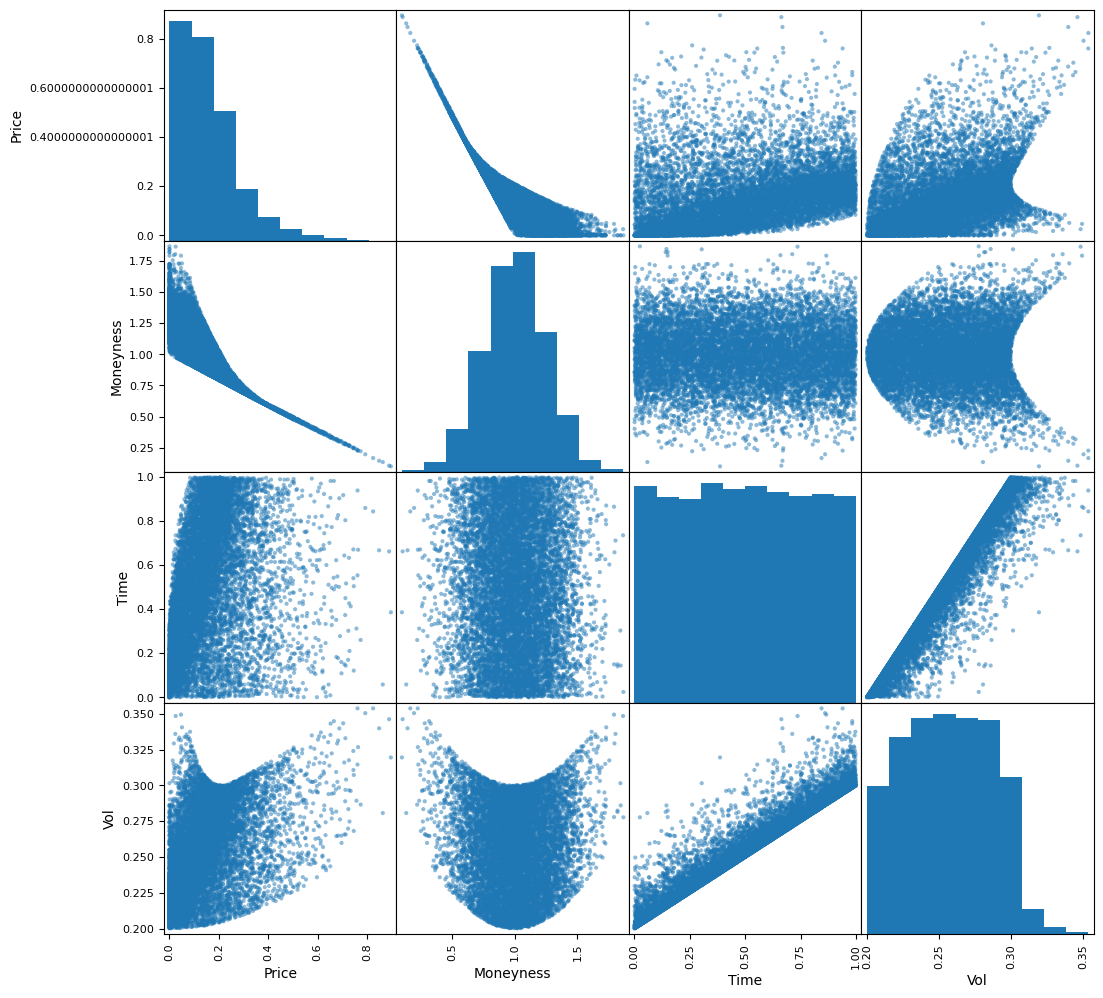

In [26]:
pyplot.figure(figsize=(15,15))
scatter_matrix(dataset,figsize=(12,12))
pyplot.show()

In [31]:
bestfeatures = SelectKBest(k='all', 
score_func=f_regression)
fit = bestfeatures.fit(X,Y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(['Moneyness', 'Time', 'Vol'])


In [33]:
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']

In [34]:
featureScores.nlargest(10,'Score').set_index('Specs')

,Score
Specs,
Moneyness,31182.417194
Vol,2049.194853
Time,1113.793976


In [37]:
from sklearn.feature_selection import f_regression

F_values, p_values = f_regression(X, Y)


In [38]:
F_values

array([31182.41719439,  1113.79397569,  2049.19485317])

In [39]:
validation_size = 0.2
train_size = int(len(X) * (1-validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

In [40]:
num_folds = 10
seed = 7
scoring = 'neg_mean_squared_error'

In [41]:
models = []
models.append(('LR', LinearRegression()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

In [43]:
models.append(('MLP', MLPRegressor()))
models.append(('ABR', AdaBoostRegressor()))
models.append(('GBR', GradientBoostingRegressor()))
models.append(('RFR', RandomForestRegressor()))
models.append(('ETR', ExtraTreesRegressor()))


In [45]:
num_folds = 10
scoring = 'neg_mean_squared_error'
names = []
kfold_results = []
test_results = []
train_results = []
for name, model in models:
    names.append(name)
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=7)
    cv_results = -1* cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    kfold_results.append(cv_results)
    res = model.fit(X_train, Y_train)
    train_result = mean_squared_error(res.predict(X_train), Y_train)
    train_results.append(train_result)
    test_result = mean_squared_error(res.predict(X_test), Y_test)
    test_results.append(test_result)

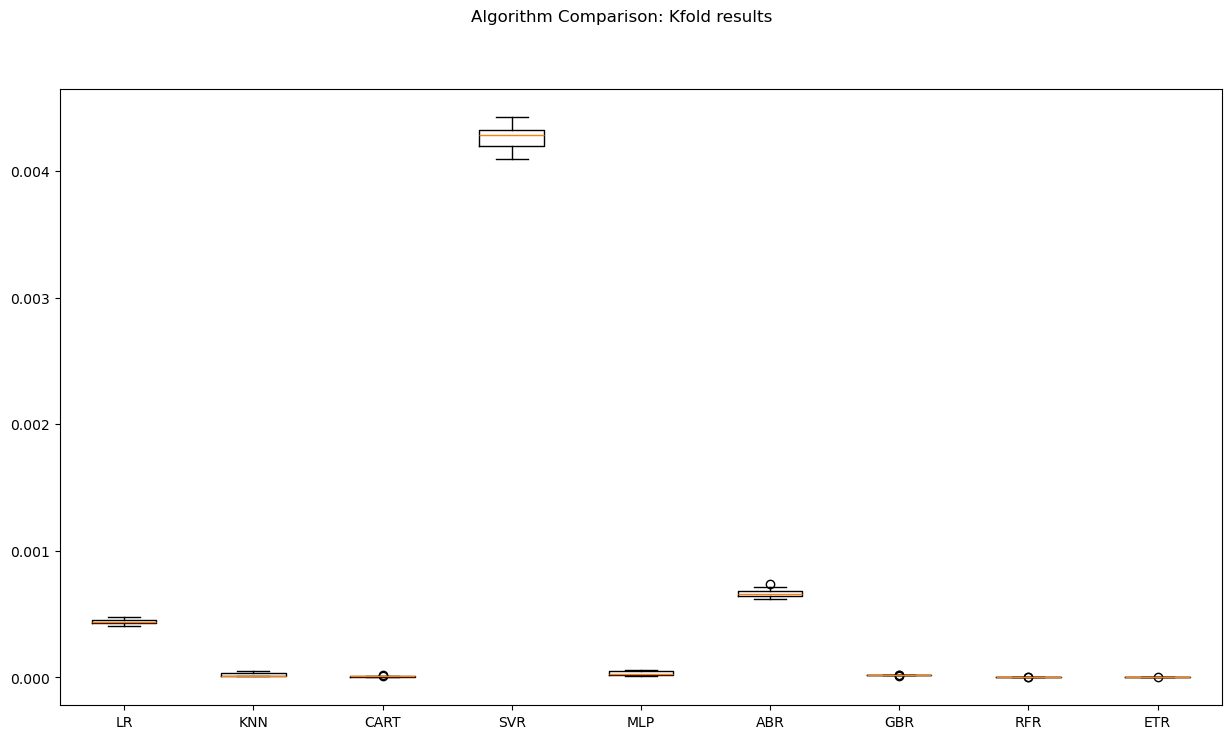

In [46]:
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison: Kfold results')
ax = fig.add_subplot(111)
pyplot.boxplot(kfold_results)
ax.set_xticklabels(names)
fig.set_size_inches(15,8)
pyplot.show()

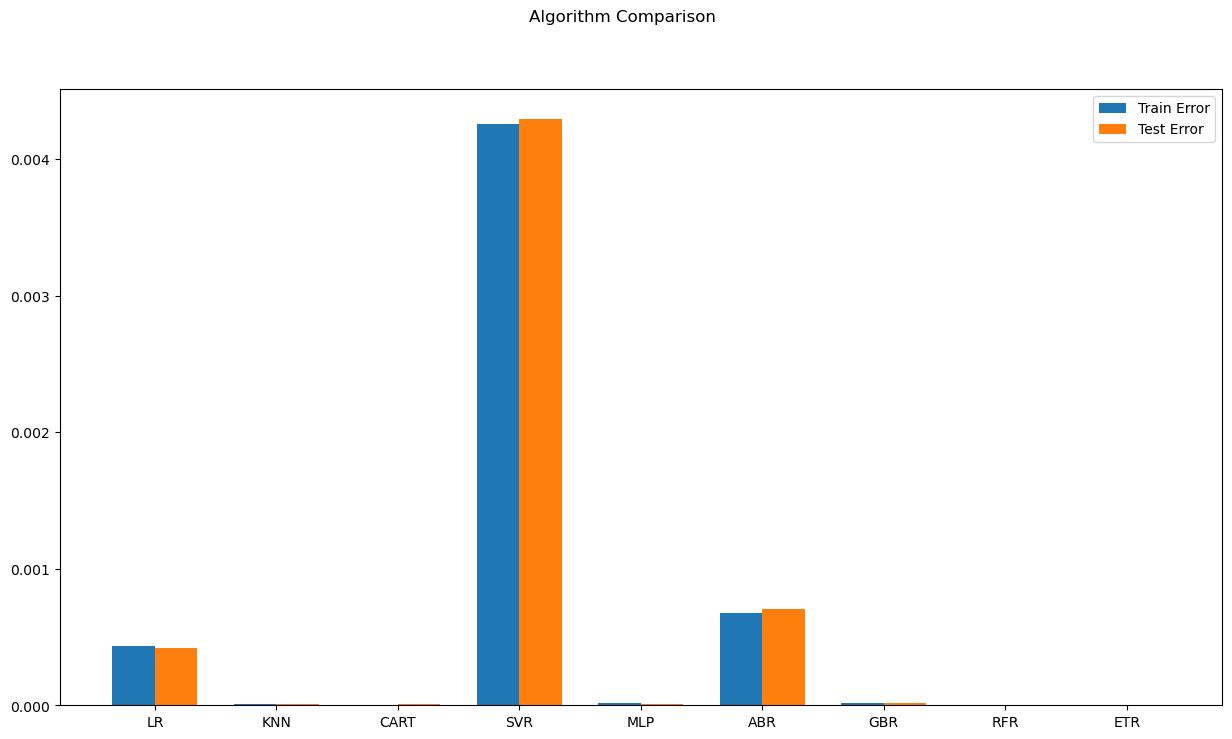

In [47]:
fig = pyplot.figure()
ind = np.arange(len(names)) 
width = 0.35 
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results,  width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

In [49]:
param_grid={'hidden_layer_sizes': [(20,), (50,),(20,20), (20, 30, 20)]}
model = MLPRegressor()
kfold = KFold(n_splits=num_folds,shuffle=True,random_state=seed)
grid = GridSearchCV(estimator=model, 
param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)
print("Best: %f using %s" % (grid_result.best_score_,grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: -0.000025 using {'hidden_layer_sizes': (20, 30, 20)}
-0.000697 (0.000683) with: {'hidden_layer_sizes': (20,)}
-0.000097 (0.000109) with: {'hidden_layer_sizes': (50,)}
-0.000097 (0.000075) with: {'hidden_layer_sizes': (20, 20)}
-0.000025 (0.000021) with: {'hidden_layer_sizes': (20, 30, 20)}


In [50]:
model_tuned = MLPRegressor(hidden_layer_sizes=(20, 30, 20))
model_tuned.fit(X_train, Y_train)

MLPRegressor(hidden_layer_sizes=(20, 30, 20))

In [51]:
predictions = model_tuned.predict(X_test)
print(mean_squared_error(Y_test, predictions))

2.7789344712691162e-05


In [52]:
X = X[:, :2]
validation_size = 0.2
train_size = int(len(X) * (1-validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

In [53]:
X_train

array([[0.89223005, 0.40348075],
       [0.98434342, 0.04630317],
       [1.17097693, 0.28069483],
       ...,
       [0.7724498 , 0.50904291],
       [0.92797549, 0.21999679],
       [1.03052168, 0.82630266]])

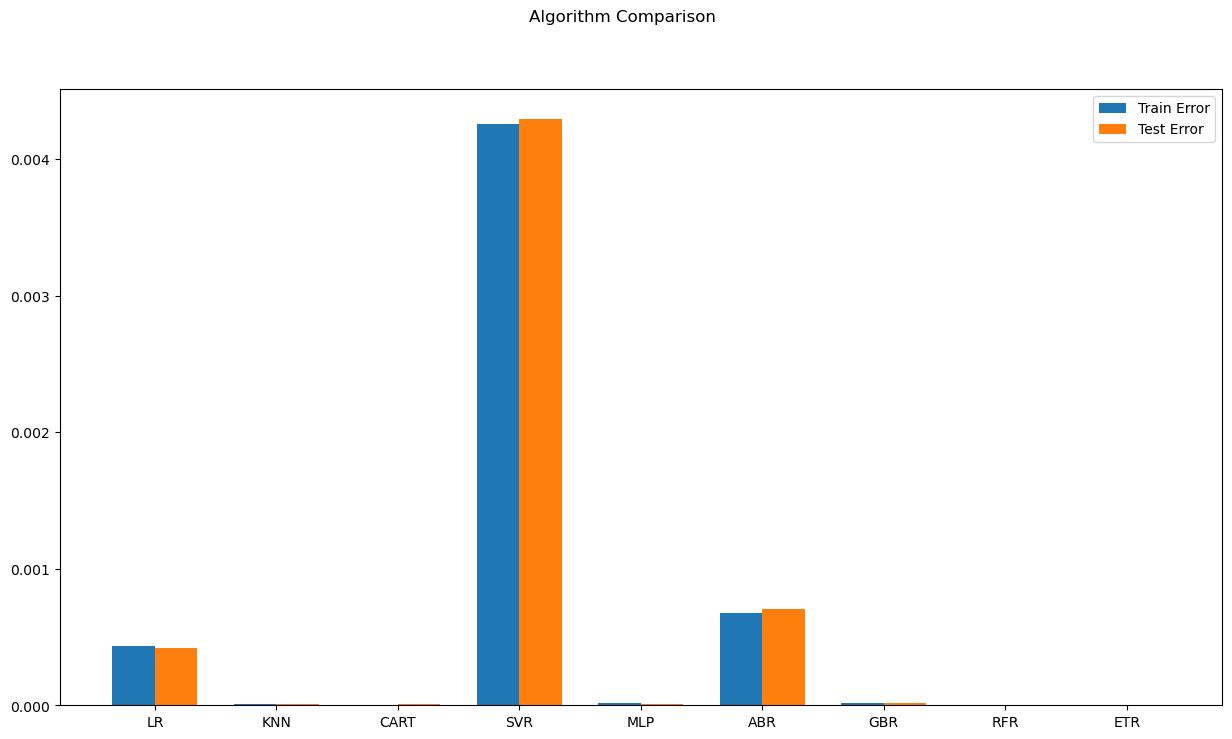

In [54]:
fig = pyplot.figure()
ind = np.arange(len(names)) 
width = 0.35 
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results,  width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()